In [1]:
import numpy as np
from numpy.typing import NDArray
from numba import njit
import matplotlib.pyplot as plt
from yennefer import RK4Solver, RK45Solver, DOP853Solver

In [2]:
OMEGA = 10.0
GAMMA = 0.1
SIGMA = 0.05
TAU   = 0.5

T_MAX    = 50.0
DT_NOISE = 0.001

rng    = np.random.default_rng()
n_pts  = int(T_MAX / DT_NOISE) + 2
t_noise = np.linspace(0.0, T_MAX, n_pts)

ou = np.zeros(n_pts)
decay       = np.exp(-DT_NOISE / TAU)
noise_scale = SIGMA * np.sqrt(1.0 - decay**2)
for i in range(1, n_pts):
    ou[i] = ou[i-1] * decay + noise_scale * rng.standard_normal()

print(f"OU stats:  mean = {ou.mean():.5f}  std = {ou.std():.5f}  (target std = {SIGMA})")

par: NDArray[np.float64] = np.concatenate([
    np.array([OMEGA, GAMMA, 0.0, DT_NOISE], dtype=np.float64),
    ou.astype(np.float64),
])
y0: NDArray[np.float64] = np.array([1.0, 0.0], dtype=np.float64)

OU stats:  mean = -0.00686  std = 0.05597  (target std = 0.05)


In [3]:
@njit
def _interp_ou(t: float, t0: float, dt_n: float, ou_arr: np.ndarray) -> float:
    idx_f = (t - t0) / dt_n
    idx   = int(idx_f)
    if idx < 0:
        return ou_arr[0]
    if idx >= len(ou_arr) - 1:
        return ou_arr[len(ou_arr) - 1]
    frac = idx_f - idx
    return ou_arr[idx] * (1.0 - frac) + ou_arr[idx + 1] * frac


@njit
def f(t: float, y: NDArray[np.float64], params: NDArray[np.float64]) -> np.ndarray:
    omega = params[0]
    gamma = params[1]
    t0    = params[2]
    dt_n  = params[3]
    xi = _interp_ou(t, t0, dt_n, params[4:])

    omega_noisy = omega + xi
    dydt = np.empty(2, dtype=np.float64)
    dydt[0] = y[1]
    dydt[1] = -omega_noisy * y[0] - gamma * y[1]
    return dydt


In [7]:
dt_init = 0.001

solver_rk4 = RK4Solver(f, y0, par)
t_rk4, y_rk4 = solver_rk4.solve(T_MAX, dt_init)

solver_rk45 = RK45Solver(f, y0, par, atol=1e-9, rtol=1e-9)
t_rk45, y_rk45 = solver_rk45.solve(T_MAX, dt_init)

solver_dop = DOP853Solver(f, y0, par, atol=1e-9, rtol=1e-9, n_max_steps=1_000_000)
t_dop, y_dop = solver_dop.solve(T_MAX, dt_init)

print(f"RK4   steps : {len(t_rk4)}")
print(f"RK45  steps : {len(t_rk45)}")
print(f"DOP853 steps: {len(t_dop)}")

RK4   steps : 50002
RK45  steps : 34755
DOP853 steps: 42282


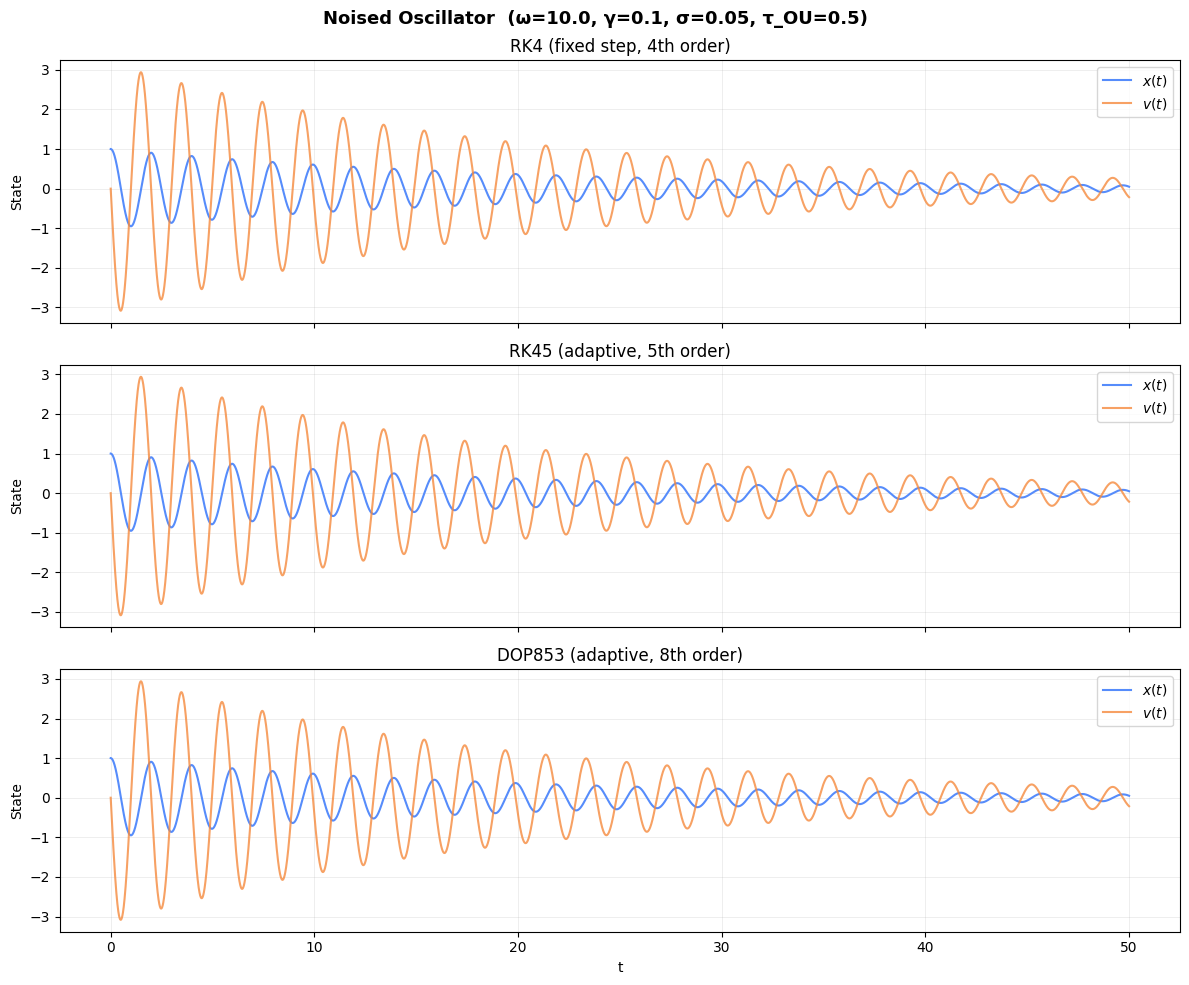

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle(
    f"Noised Oscillator  (ω={OMEGA}, γ={GAMMA}, σ={SIGMA}, τ_OU={TAU})",
    fontsize=13, fontweight="bold",
)

configs = [
    (axes[0], t_rk4,  y_rk4,  "RK4 (fixed step, 4th order)"),
    (axes[1], t_rk45, y_rk45, "RK45 (adaptive, 5th order)"),
    (axes[2], t_dop,  y_dop,  "DOP853 (adaptive, 8th order)"),
]
for (ax, T, Y, title) in configs:
    ax.plot(T, Y[:, 0], label=r"$x(t)$")
    ax.plot(T, Y[:, 1], label=r"$v(t)$", alpha=0.8)
    ax.set_title(title)
    ax.set_ylabel("State")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("t")
plt.tight_layout()
plt.show()

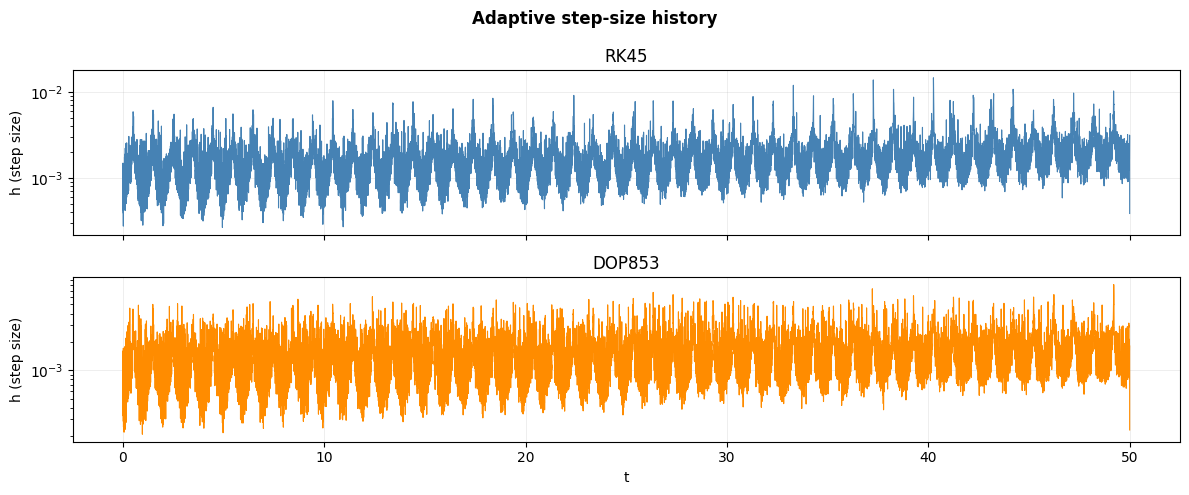

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
fig.suptitle("Adaptive step-size history", fontsize=12, fontweight="bold")

ax1.semilogy(t_rk45[:-1], np.diff(t_rk45), color="steelblue", lw=0.8)
ax1.set_title("RK45")
ax1.set_ylabel("h (step size)")
ax1.grid(True, alpha=0.3)

ax2.semilogy(t_dop[:-1], np.diff(t_dop), color="darkorange", lw=0.8)
ax2.set_title("DOP853")
ax2.set_ylabel("h (step size)")
ax2.set_xlabel("t")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()